In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.array([-200., -400., -600.])
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


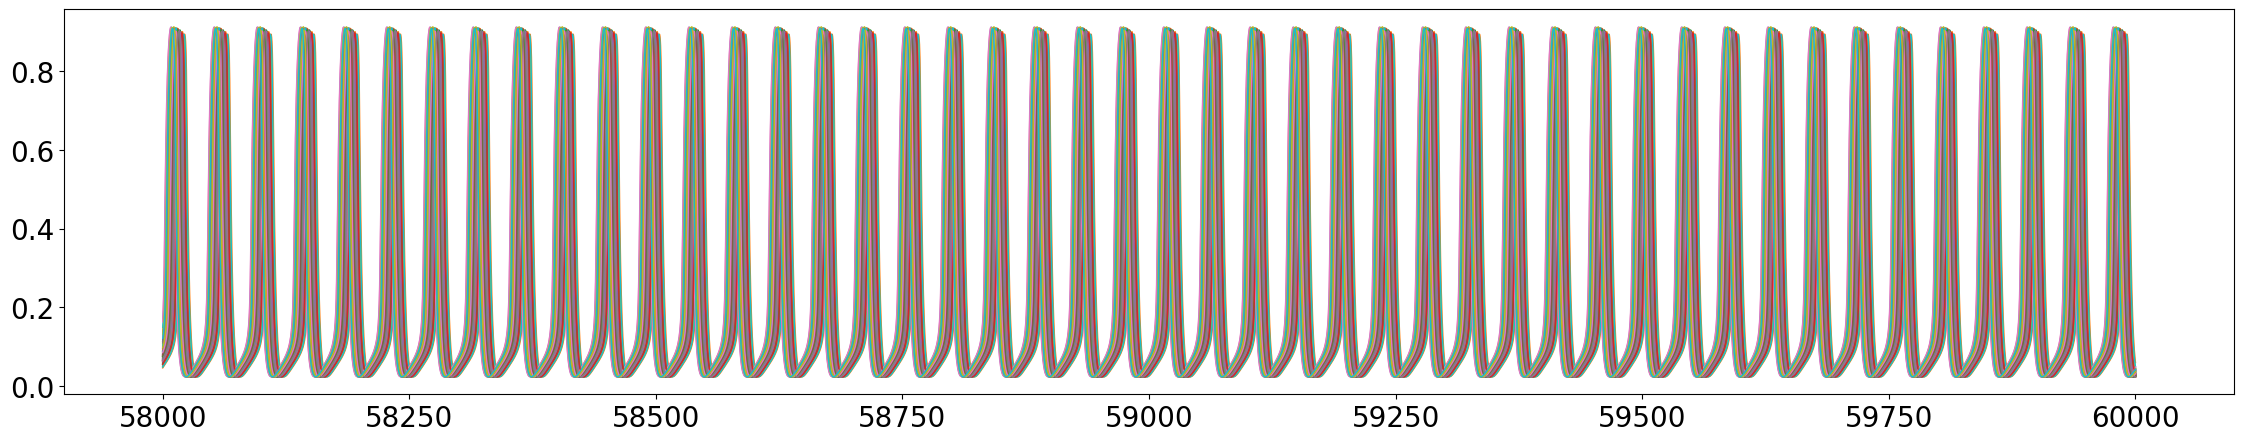

/home/lena/Promotion/neurolib/neurolib/control/optimal_control/cost_functions.py:334: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'getmean_vt'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 313:
@numba.njit
def getmean_vt(
^

  xmean = getmean_vt(x_sim, interval)
/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'var_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", lin

0.032164549250778954


/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'cc_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 413:
@numba.njit
def cc_cost(
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


-0.6242257109598518
------------------- seed =  25


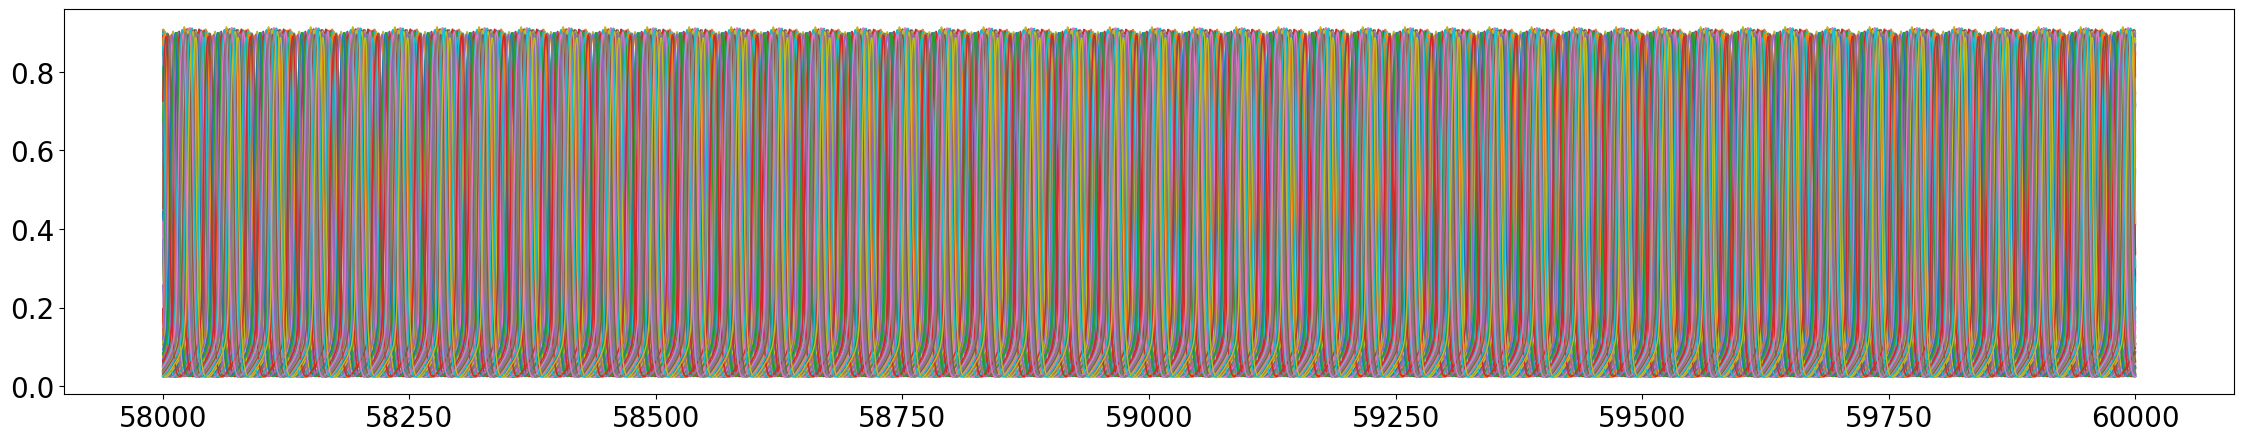

0.08426829728692982
-0.025985539150927384


In [7]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

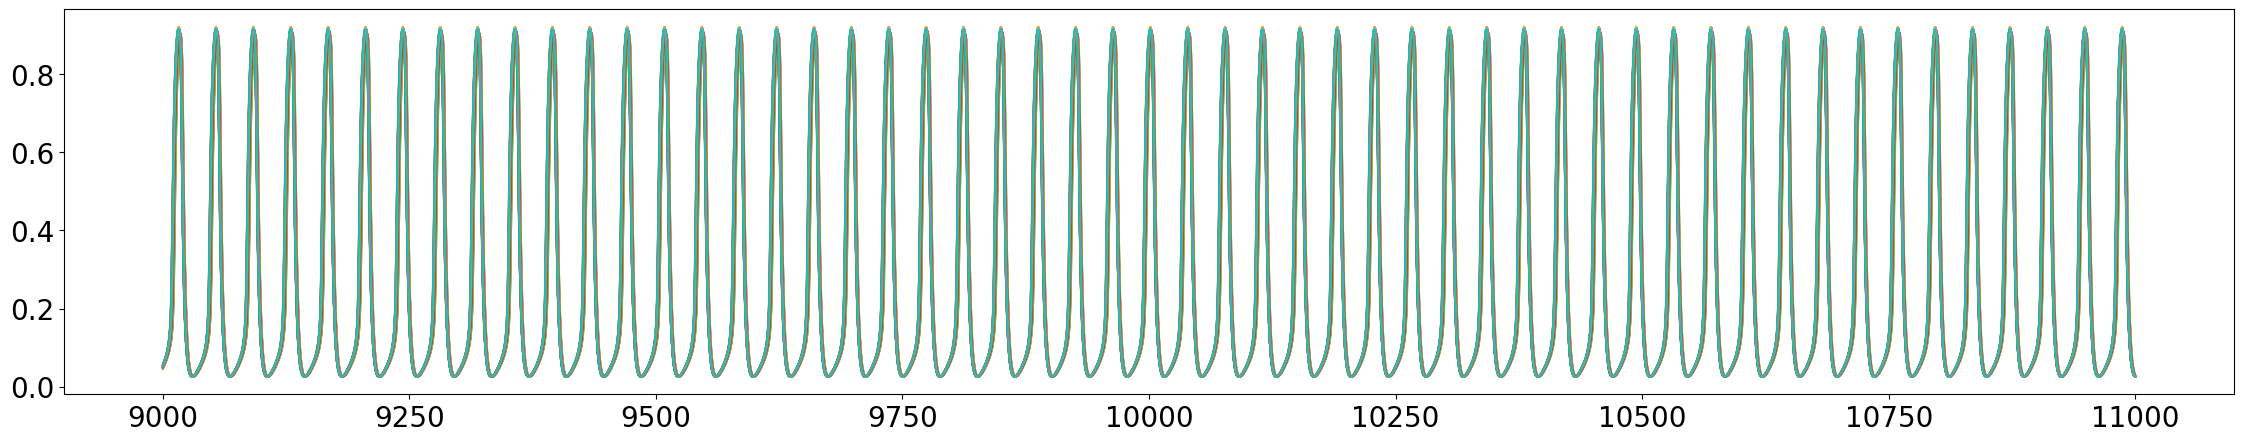

0.002332105821483664
-0.9775374609292389


In [8]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2_L1["init_state"] = [einit, iinit]
data_2_L1["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0_L1, data_1_L1, data_2_L1] = data_read

############ control task 0

In [8]:
it = 4

for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    if wi not in [1,2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_0_L1["init_state"][0]
    model.params.inh_init = data_0_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_0_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_0_L1["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_0_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    # find initial signal
    model_controlled.channelwise_optimization = True
    model_controlled.optimize(1)

    data_0_L1["control"][wi] = model_controlled.control.copy()
    data_0_L1["state"][wi] = model_controlled.get_xs()
    data_0_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
    data_0_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_0_L1["energy_input"][wi])/data_0_L1["weights"][wi]

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(-2, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_0_L1["control"][wi] = model_controlled.control.copy()
            data_0_L1["state"][wi] = model_controlled.get_xs()
            data_0_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_0_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_0_L1["energy_input"][wi])/data_0_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

        model_controlled.grad_method = 1

        for k in range(-2, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_0_L1["control"][wi] = model_controlled.control.copy()
            data_0_L1["state"][wi] = model_controlled.get_xs()
            data_0_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_0_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_0_L1["energy_input"][wi])/data_0_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

------------------------------------------------------------ wi =  0
------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -12.849935354232212
Cost in iteration 1: -16.53516240999918
Final cost : -16.53516240999918
Compute control for a deterministic system
Cost in iteration 0: -16.53516240999918


SystemError: CPUDispatcher(<function timeIntegration_njit_elementwise at 0x7eb6543eeef0>) returned a result with an exception set

In [10]:
with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
    pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

------------------------------------------------------------ wi =  0
------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -16.53516240999918
Final cost : -16.53516240999918
Compute control for a deterministic system
Cost in iteration 0: -16.53516240999918
Cost in iteration 1: -16.53516533490381
Cost in iteration 2: -16.53516865129727
Cost in iteration 3: -16.53517490737545
Cost in iteration 4: -16.5351872396647
Final cost : -16.5351872396647
Compute control for a deterministic system
Cost in iteration 0: -16.5351872396647
Cost in iteration 1: -16.535331067402502
Cost in iteration 2: -16.53558690811986
Cost in iteration 3: -16.53597970205104
Cost in iteration 4: -16.536747709496623
Final cost : -16.536747709496623
Compute control for a deterministic system
Cost in iteration 0: -16.536747709496623
Cost in iteration 1: -16.543205993458802
Cost in iteration 2: -16.

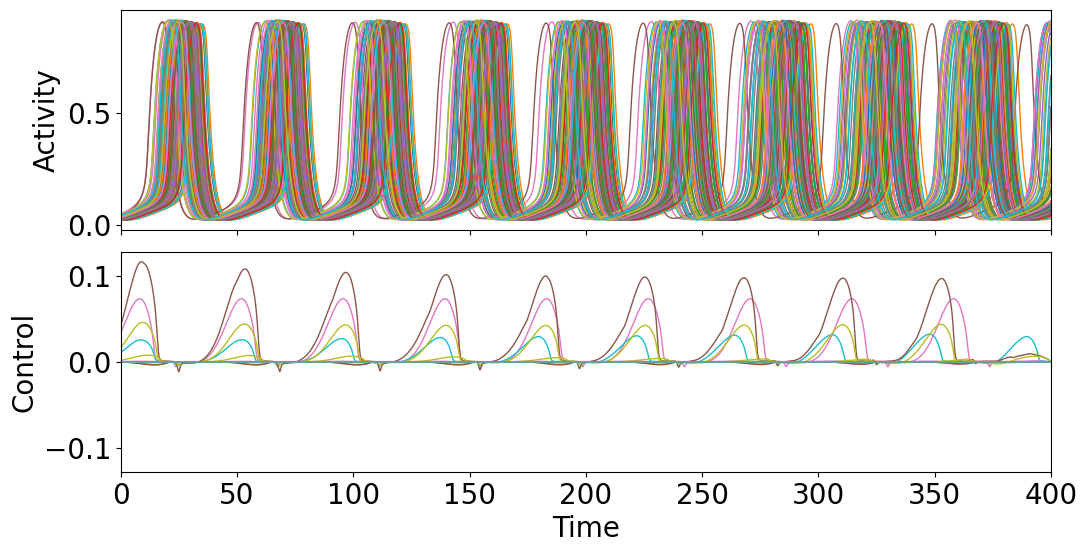

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -30.44720243895253
Final cost : -30.44720243895253
Compute control for a deterministic system
Cost in iteration 0: -30.44720243895253
Cost in iteration 1: -30.447436591275586
Cost in iteration 2: -30.447904858314708
Cost in iteration 3: -30.448841241469566
Cost in iteration 4: -30.450713400132557
Final cost : -30.450713400132557
Compute control for a deterministic system
Cost in iteration 0: -30.450713400132557
Cost in iteration 1: -30.474070824272587
Cost in iteration 2: -30.520329925361647
Cost in iteration 3: -30.610415067284674
Cost in iteration 4: -30.774908205311185
Final cost : -30.774908205311185
Compute control for a deterministic system
Cost in iteration 0: -30.774908205311185
Cost in iteration 1: -31.094591874749725
Cost in iteration 2: -31.137334402511712
Cost in iteration 3: -31.17669988613993
Co

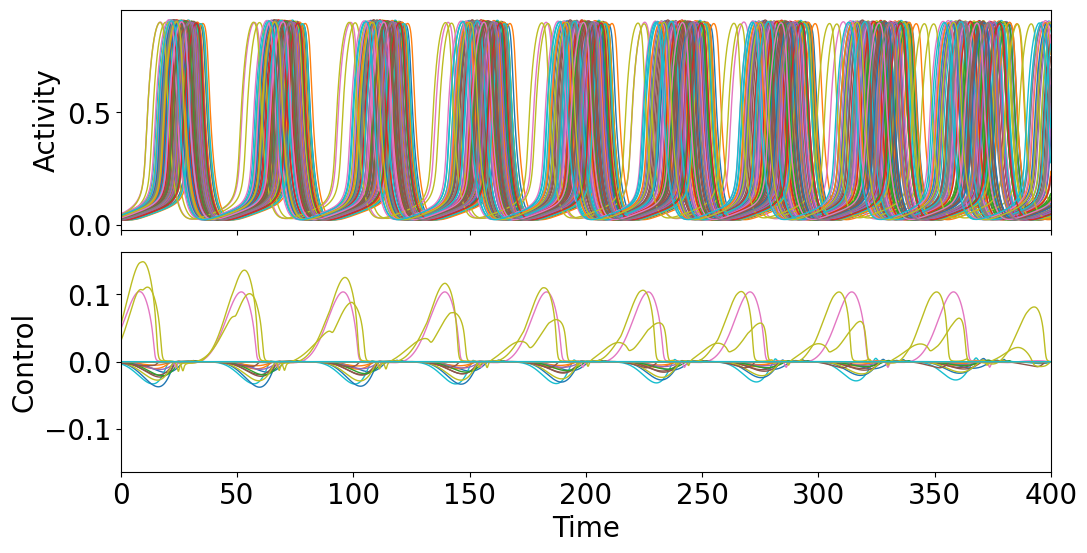

In [9]:
it = 4

for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    if wi not in [1,2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_0_L1["init_state"][0]
    model.params.inh_init = data_0_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_0_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_0_L1["coordinates"][1]
    model.params.duration = duration
    dt = model.params.dt

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_0_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    model_controlled.control = data_0_L1["control"][wi].copy()
    model_controlled.update_input()
    model_controlled.simulate_forward()
    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(-4, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_0_L1["control"][wi] = model_controlled.control.copy()
            data_0_L1["state"][wi] = model_controlled.get_xs()
            data_0_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_0_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_0_L1["energy_input"][wi])/data_0_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

        model_controlled.grad_method = 1

        for k in range(-4, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_0_L1["control"][wi] = model_controlled.control.copy()
            data_0_L1["state"][wi] = model_controlled.get_xs()
            data_0_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_0_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_0_L1["energy_input"][wi])/data_0_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

###################### control task 1

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 169.44984611257846
Cost in iteration 1: 169.44984611257846
Final cost : 169.44984611257846
Compute control for a deterministic system
Cost in iteration 0: 169.44984611257846
Cost in iteration 1: 168.88178853931788
Cost in iteration 2: 168.2768485244851
Cost in iteration 3: 167.21314325293167
Cost in iteration 4: 164.84789047418718
Final cost : 164.84789047418718
Compute control for a deterministic system
Cost in iteration 0: 164.84789047418718
Cost in iteration 1: 163.92254464863174
Cost in iteration 2: 163.41285510240775
Cost in iteration 3: 162.156313209185
Cost in iteration 4: 161.8395852933127
Final cost : 161.8395852933127
Compute control for a deterministic system
Cost in iteration 0: 161.8395852933127
Cost in iteration 1: 159.83650393554106
Cost in iteration 2: 159.4578687175081
Cost in iteration 3: 15

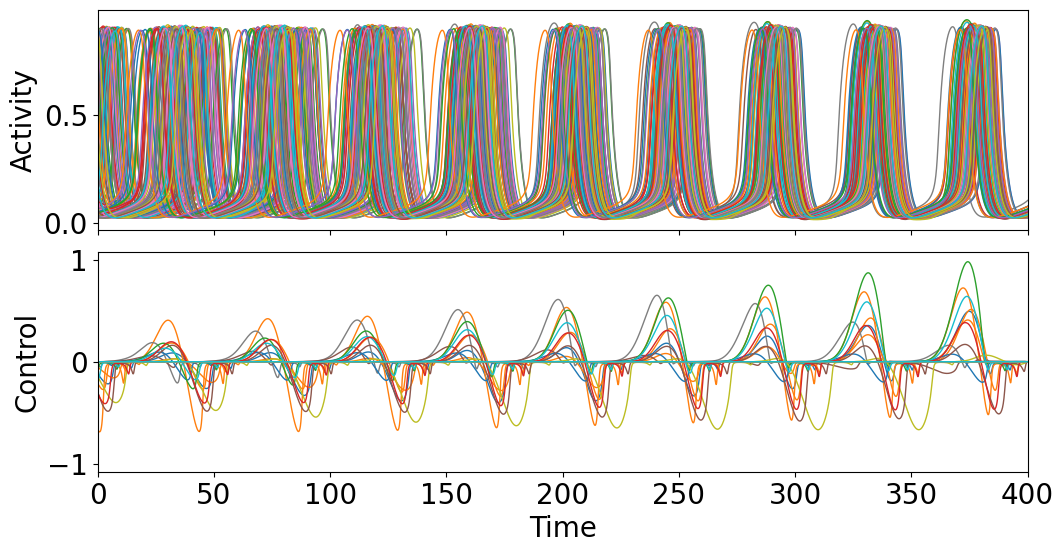

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 338.8996922251569
Cost in iteration 1: 338.7000000541474
Final cost : 338.7000000541474
Compute control for a deterministic system
Cost in iteration 0: 338.7000000541474
Cost in iteration 1: 336.9300744766955
Cost in iteration 2: 332.35441861797614
Cost in iteration 3: 331.49882333737924
Cost in iteration 4: 331.27651167134127
Final cost : 331.27651167134127
Compute control for a deterministic system
Cost in iteration 0: 331.27651167134127
Cost in iteration 1: 321.9365949591938
Cost in iteration 2: 319.1832306679039
Cost in iteration 3: 317.35903444337134
Cost in iteration 4: 313.20874653136065
Final cost : 313.20874653136065
Compute control for a deterministic system
Cost in iteration 0: 313.20874653136065
Cost in iteration 1: 312.75924428652615
Cost in iteration 2: 311.6000213626729
Cost in iteration 3: 302

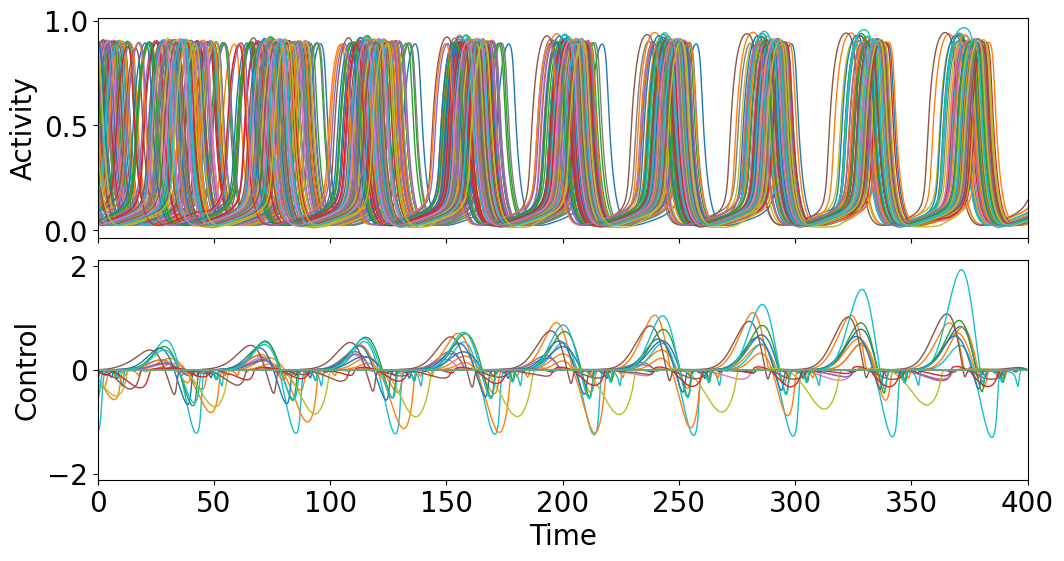

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 508.34953833773494
Cost in iteration 1: 505.9395197338594
Final cost : 505.9395197338594
Compute control for a deterministic system
Cost in iteration 0: 505.9395197338594
Cost in iteration 1: 501.93504712460077
Cost in iteration 2: 499.0448279096732
Cost in iteration 3: 497.5041427555507
Cost in iteration 4: 494.66209948456435
Final cost : 494.66209948456435
Compute control for a deterministic system
Cost in iteration 0: 494.66209948456435
Cost in iteration 1: 494.2963002783173
Cost in iteration 2: 482.0776297934775
Cost in iteration 3: 479.68727793021947
Cost in iteration 4: 475.63241071385966
Final cost : 475.63241071385966
Compute control for a deterministic system
Cost in iteration 0: 475.63241071385966
Cost in iteration 1: 474.6485626518373
Cost in iteration 2: 465.63214222306624
Cost in iteration 3: 457

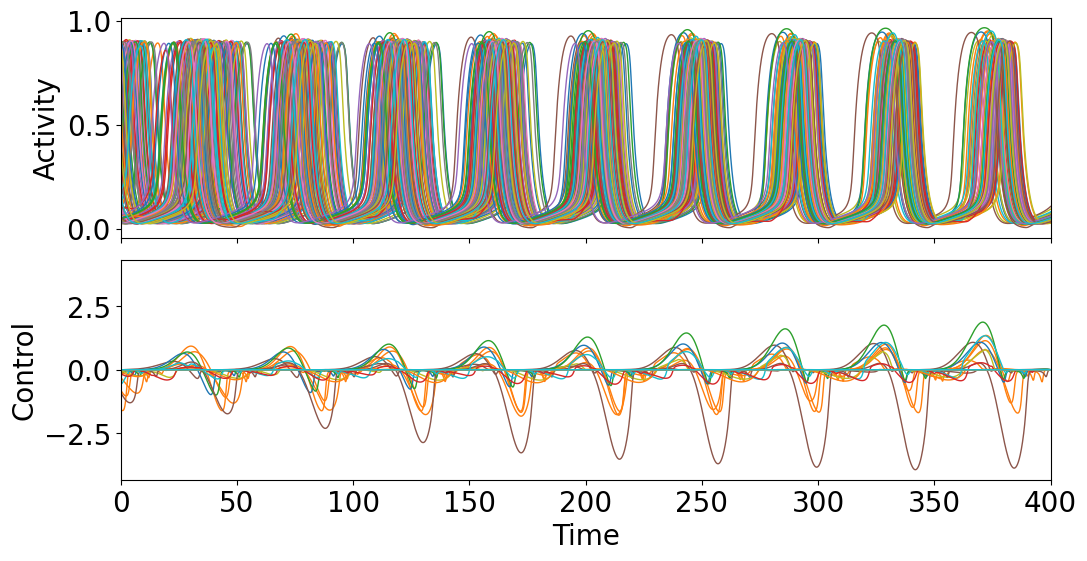

In [27]:
it = 4

for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    #if wi not in [0]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_1_L1["init_state"][0]
    model.params.inh_init = data_1_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_1_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_1_L1["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_1_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    # find initial signal
    model_controlled.channelwise_optimization = True
    model_controlled.step = 1e6
    model_controlled.optimize(1)

    data_1_L1["control"][wi] = model_controlled.control.copy()
    data_1_L1["state"][wi] = model_controlled.get_xs()
    data_1_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
    data_1_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_1_L1["energy_input"][wi])/data_1_L1["weights"][wi]

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(4, 8, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_1_L1["control"][wi] = model_controlled.control.copy()
            data_1_L1["state"][wi] = model_controlled.get_xs()
            data_1_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_1_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_1_L1["energy_input"][wi])/data_1_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

        model_controlled.grad_method = 1

        for k in range(2, 6, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_1_L1["control"][wi] = model_controlled.control.copy()
            data_1_L1["state"][wi] = model_controlled.get_xs()
            data_1_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_1_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_1_L1["energy_input"][wi])/data_1_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

In [7]:
it = 4

for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    #if wi not in [2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_1_L1["init_state"][0]
    model.params.inh_init = data_1_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_1_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_1_L1["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_1_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    if type(data_1_L1["control"][wi]) != type(None):
        model_controlled.control = data_1_L1["control"][wi].copy()
        model_controlled.update_input()
    model_controlled.channelwise_optimization = True
    model_controlled.optimize(1)

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(-2, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_1_L1["control"][wi] = model_controlled.control.copy()
            data_1_L1["state"][wi] = model_controlled.get_xs()
            data_1_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_1_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_1_L1["energy_input"][wi])/data_1_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

        model_controlled.grad_method = 1

        for k in range(-2, 4, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_1_L1["control"][wi] = model_controlled.control.copy()
            data_1_L1["state"][wi] = model_controlled.get_xs()
            data_1_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_1_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_1_L1["energy_input"][wi])/data_1_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 156.1175822030911
Cost in iteration 1: 155.087687133522
Final cost : 155.087687133522
Compute control for a deterministic system
Cost in iteration 0: 155.087687133522
Cost in iteration 1: 155.05697996564908
Cost in iteration 2: 154.99628352266313
Cost in iteration 3: 154.87769591821055
Cost in iteration 4: 154.65125643894885
Final cost : 154.65125643894885
Compute control for a deterministic system
Cost in iteration 0: 154.65125643894885
Cost in iteration 1: 152.94211381082434
Cost in iteration 2: 150.9006743725971
Cost in iteration 3: 149.03125034155693
Cost in iteration 4: 147.22274665965483
Final cost : 147.22274665965483
Compute control for a deterministic system
Cost in iteration 0: 147.22274665965483
Cost in iteration 1: 147.22255779610714
Cost in iteration 2: 147.21863710701146
Cost in iteration 3: 147

KeyboardInterrupt: 

###################### control task 3

In [7]:
data_2_L1["weights"] = [-400., -600., -800.]

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -1.1880561610770324
Cost in iteration 1: -1.6799135458764858
Cost in iteration 2: -1.6799135458764858
Final cost : -1.6799135458764858


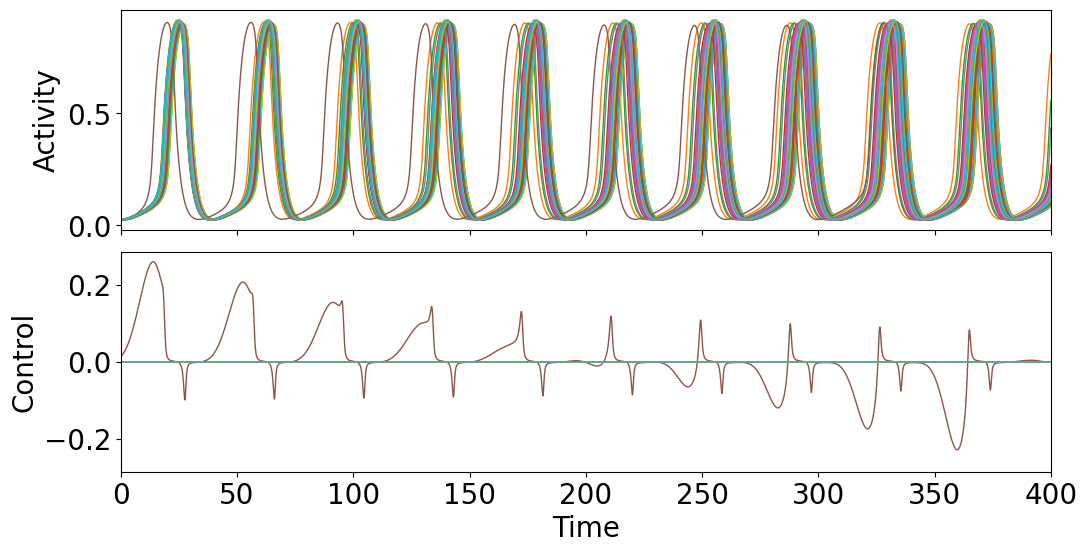

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -1.782084241615546
Cost in iteration 1: -1.9279168463280394
Cost in iteration 2: -1.9279168463280394
Final cost : -1.9279168463280394


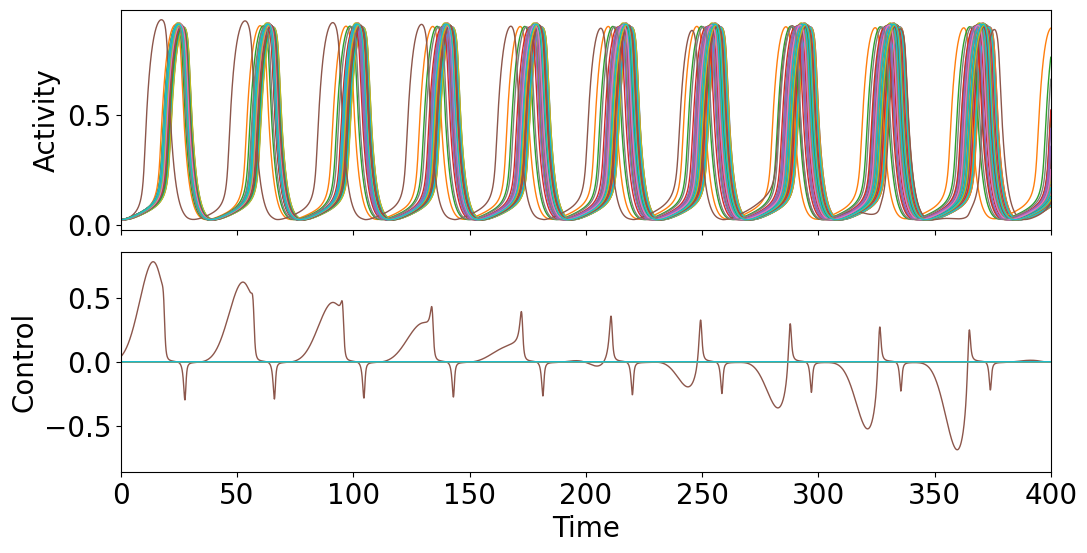

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -2.3761123221540648
Cost in iteration 1: -5.730696886250695
Cost in iteration 2: -7.483021399247235
Final cost : -7.483021399247235


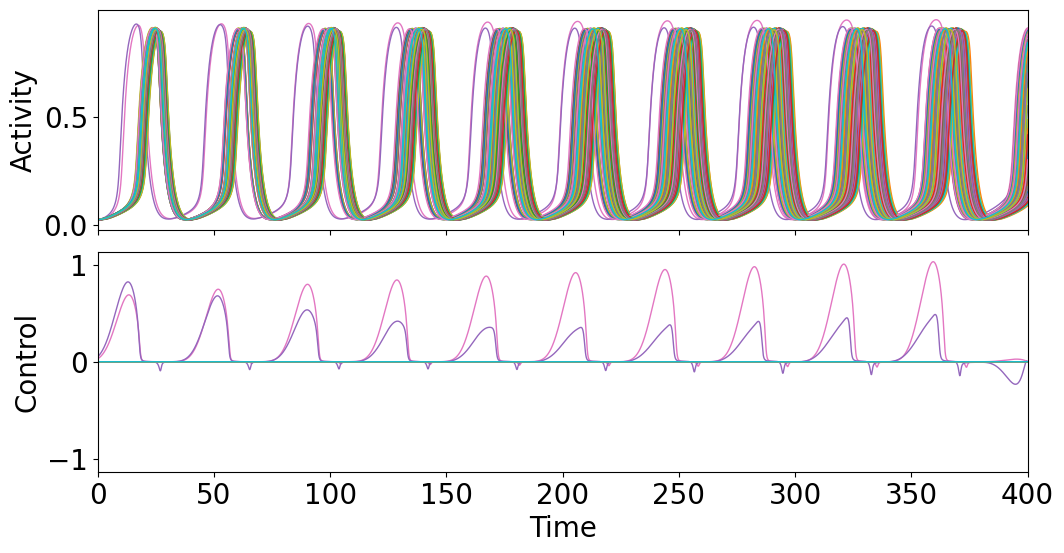

In [8]:
for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_2_L1["init_state"][0]
    model.params.inh_init = data_2_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_2_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_2_L1["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_2_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    # find initial signal
    model_controlled.channelwise_optimization = True
    model_controlled.step = 1e6
    model_controlled.optimize(2)

    data_2_L1["control"][wi] = model_controlled.control.copy()
    data_2_L1["state"][wi] = model_controlled.get_xs()
    data_2_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
    data_2_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_2_L1["energy_input"][wi])/data_2_L1["weights"][wi]

    with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
        pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -6.226628007611078
Cost in iteration 1: -6.229608717879021
Final cost : -6.229608717879021
Compute control for a deterministic system
Cost in iteration 0: -6.229608717879021
Cost in iteration 1: -6.477834629508992
Cost in iteration 2: -6.4888436137746
Cost in iteration 3: -6.489327262600034
Cost in iteration 4: -6.49002024510175
Final cost : -6.49002024510175
Compute control for a deterministic system
Cost in iteration 0: -6.49002024510175
Cost in iteration 1: -6.49002024510175
Cost in iteration 2: -6.49002024510175
Converged in iteration 2 with cost -6.49002024510175
Final cost : -6.49002024510175
Compute control for a deterministic system
Cost in iteration 0: -6.49002024510175
Cost in iteration 1: -6.49002024510175
Cost in iteration 2: -6.49002024510175
Converged in iteration 2 with cost -6.49002024510175
F

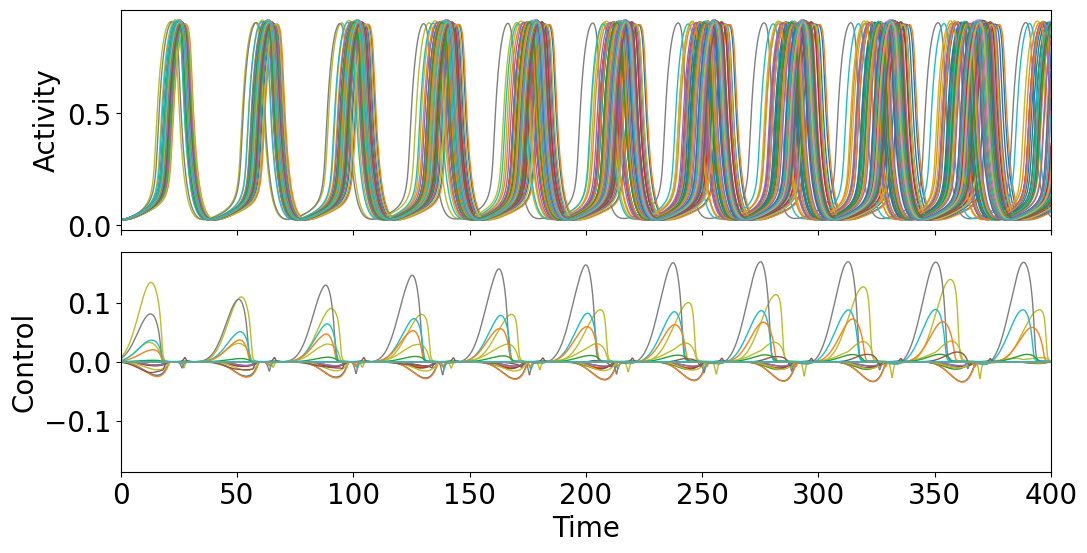

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -13.058503512953857
Cost in iteration 1: -13.06097718184811
Final cost : -13.06097718184811
Compute control for a deterministic system
Cost in iteration 0: -13.06097718184811
Cost in iteration 1: -13.064971558739721
Cost in iteration 2: -13.07178839704185
Cost in iteration 3: -13.084425722798205
Cost in iteration 4: -13.093749514204681
Final cost : -13.093749514204681
Compute control for a deterministic system
Cost in iteration 0: -13.093749514204681
Cost in iteration 1: -13.096726781263161
Cost in iteration 2: -13.139222550319202
Cost in iteration 3: -13.144865057682114
Cost in iteration 4: -13.148881069898096
Final cost : -13.148881069898096
Compute control for a deterministic system
Cost in iteration 0: -13.148881069898096
Cost in iteration 1: -13.149745535662102
Cost in iteration 2: -13.150144252805923
Co

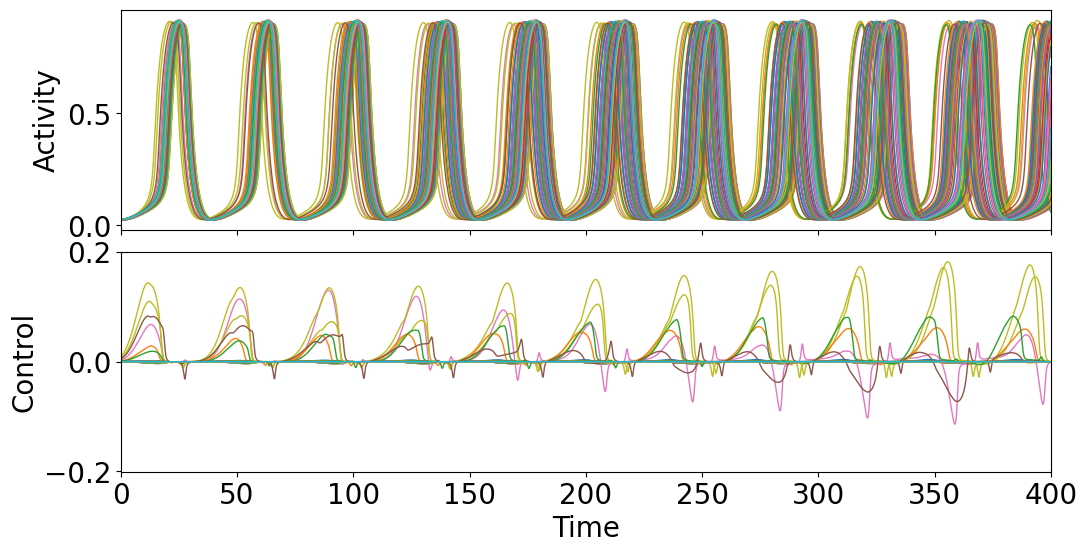

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -25.4651438956573
Cost in iteration 1: -25.51192810752317
Final cost : -25.51192810752317
Compute control for a deterministic system
Cost in iteration 0: -25.51192810752317
Cost in iteration 1: -25.512541458004364
Cost in iteration 2: -25.53265279791135
Cost in iteration 3: -25.546189392187404
Cost in iteration 4: -25.566108321325345
Final cost : -25.566108321325345
Compute control for a deterministic system
Cost in iteration 0: -25.566108321325345
Cost in iteration 1: -25.566619212839562
Cost in iteration 2: -25.572051464416127
Cost in iteration 3: -25.573263590479538
Cost in iteration 4: -25.59288540379531
Final cost : -25.59288540379531
Compute control for a deterministic system
Cost in iteration 0: -25.59288540379531
Cost in iteration 1: -25.5970167675165
Cost in iteration 2: -25.599251315675772
Cost in i

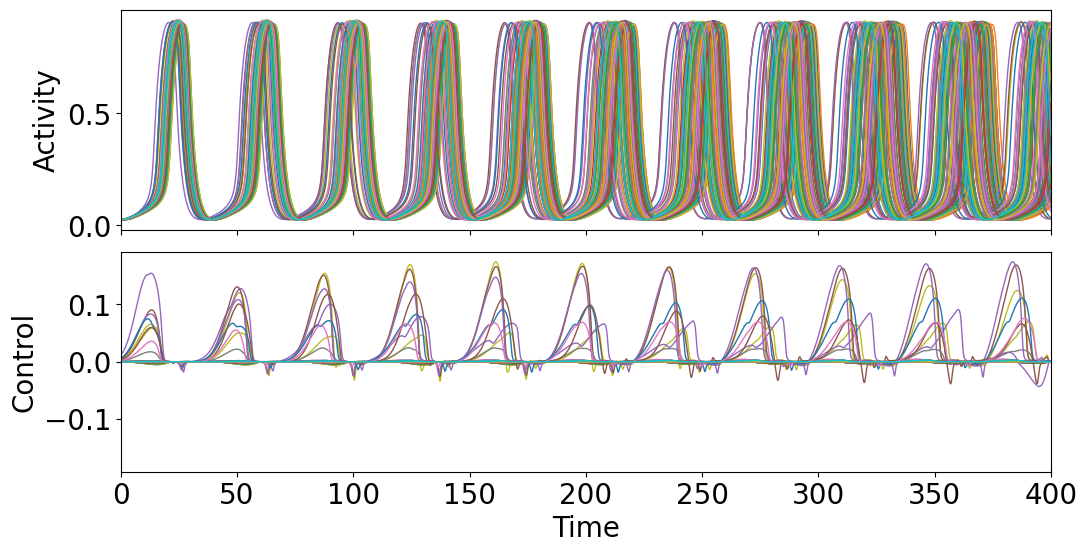

In [10]:
it = 4

for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    #if wi not in [2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data_2_L1["init_state"][0]
    model.params.inh_init = data_2_L1["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data_2_L1["coordinates"][0]
    model.params["inh_ext_baseline"] =  data_2_L1["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data_2_L1["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    if type(data_2_L1["control"][wi]) != type(None):
        model_controlled.control = data_2_L1["control"][wi].copy()
        model_controlled.update_input()
    model_controlled.channelwise_optimization = True
    model_controlled.optimize(1)

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(0, 6, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_2_L1["control"][wi] = model_controlled.control.copy()
            data_2_L1["state"][wi] = model_controlled.get_xs()
            data_2_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_2_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_2_L1["energy_input"][wi])/data_2_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

        model_controlled.grad_method = 1

        for k in range(0, 6, 2):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            data_2_L1["control"][wi] = model_controlled.control.copy()
            data_2_L1["state"][wi] = model_controlled.get_xs()
            data_2_L1["energy_input"][wi] = cost_functions.control_strength_cost(model_controlled.control, weights, dt)
            data_2_L1["sync_cost"][wi] = (model_controlled.compute_total_cost() - data_2_L1["energy_input"][wi])/data_2_L1["weights"][wi]

            with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
                pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)